In [308]:
import random
import math
class Value:
  def __init__(self,data,_children=(),_op=''):
    self.data=data
    self.grad=0.0
    self._backward=lambda:None
    self._prev=set(_children)
    self._op=_op

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out=Value(self.data+other.data,(self,other),'+')
    def _backward():
      self.grad+=1.0*out.grad
      other.grad+=1.0*out.grad
    out._backward=_backward
    return out

  def __mul__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out=Value(self.data*other.data,(self,other),'*')
    def _backward():
      self.grad+=other.data*out.grad
      other.grad+=self.data*out.grad
    out._backward=_backward
    return out

  def tanh(self):
    x=self.data
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out=Value(t,(self,),'tanh')
    def _backward():
      self.grad+=(1-t**2)*out.grad
    out._backward=_backward
    return out

  def exp(self):
    x=self.data
    t=math.exp(x)
    out=Value(t,(self,),'exp')
    def _backward():
      self.grad+=out.data*out.grad
    out._backward=_backward
    return out

  def __pow__(self,other):
    assert isinstance(other,(int,float))
    out=Value(self.data**other,(self,),'exp')
    def _backward():
      self.grad+=other*(self.data**(other-1))*out.grad
    out._backward=_backward
    return out

  def relu(self):
    out= Value(0 if self.data<0 else self.data,(self,),'relu')
    def _backward():
      self.grad+=(out.data>0)*out.grad
    out._backward=_backward
    return out

  def __radd__(self,other):
    return self+other

  def __rmul__(self,other):
    return self*other

  def __truediv__(self,other):
    return self*(other**-1)

  def __neg__(self):
    return -1*self

  def __sub__(self,other):
    return self+(-other)

  def backward(self):
    topo=[]
    visited=set()
    def bound_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          bound_topo(child)
        topo.append(v)
    bound_topo(self)
    self.grad=1.0
    for node in reversed(topo):
      node._backward()

In [309]:
class Module:
  def zero_grad(self):
    for p in self.parameters():
      p.grad=0

  def parameters(self):
    return []

class Neuron(Module):
  def __init__(self,nin,nonlin=True):
    self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b=Value(random.uniform(-1,1))
    self.nonlin=nonlin
  def __call__(self,x):
    act=sum((xi*wi for wi,xi in zip(self.w,x)),self.b)
    return act.relu() if self.nonlin else act
  def parameters(self):
    return self.w+[self.b]

class Layer(Module):
  def __init__(self,nin,nout,**kwargs):
    self.neurons=[Neuron(nin,**kwargs) for _ in range(nout)]
  def __call__(self,x):
    out=[n(x) for n in self.neurons]
    return out[0] if len(out)==1 else out
  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]

class MLP(Module):
  def __init__(self,nin,nouts):
    sz=[nin]+nouts
    self.layers=[Layer(sz[i],sz[i+1],nonlin=i!=len(nouts)-1) for i in range(len(nouts))]
  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [314]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1337)
random.seed(1337)

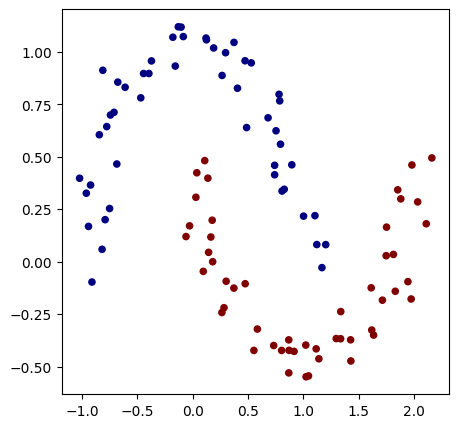

In [315]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [316]:
# initialize a model
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

number of parameters 337


In [317]:
# loss function
def loss(batch_size=None):

    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # forward the model to get scores
    scores = list(map(model, inputs))

    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss

    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=1.1815924818239036) 0.5


In [318]:
for k in range(100):

    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 1.1815924818239036, accuracy 50.0%
step 1 loss 3.1226290762065814, accuracy 50.0%
step 2 loss 0.9954343872910139, accuracy 66.0%
step 3 loss 0.9268451125083013, accuracy 50.0%
step 4 loss 0.45763213308760353, accuracy 78.0%
step 5 loss 0.4117224237975212, accuracy 90.0%
step 6 loss 0.86571087276846, accuracy 78.0%
step 7 loss 0.2916688781130028, accuracy 88.0%
step 8 loss 0.2615831275066244, accuracy 89.0%
step 9 loss 0.26197896278202026, accuracy 88.0%
step 10 loss 0.3176038682804336, accuracy 89.0%
step 11 loss 0.23983920971261063, accuracy 90.0%
step 12 loss 0.3149988422161902, accuracy 89.0%
step 13 loss 0.25036834450082257, accuracy 89.0%
step 14 loss 0.32130143236036357, accuracy 90.0%
step 15 loss 0.21742970390898123, accuracy 91.0%
step 16 loss 0.2404586527669329, accuracy 90.0%
step 17 loss 0.20309775178007372, accuracy 92.0%
step 18 loss 0.292120506856273, accuracy 89.0%
step 19 loss 0.1973387125727353, accuracy 91.0%
step 20 loss 0.22577744378801215, accuracy 92.

(-1.548639298268643, 1.951360701731357)

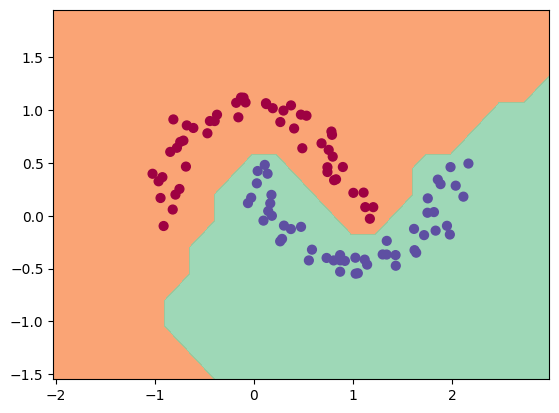

In [319]:
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())